# FPL Decision Support System — Modelling Notebook
**Thesis Project** | PyCaret AutoML vs AutoKeras Deep Learning

---
### ⚠️ Before running anything:
1. Go to `Runtime` → `Change runtime type` → select **T4 GPU** and runtime version **2025.07** → Save
2. Follow the instructions carefully — there is a required runtime restart between sections

### Pipeline
- **Section 1** — Mount Drive + Install PyCaret → ⚠️ Restart Runtime
- **Section 2** — Load & Prepare Data
- **Section 3** — PyCaret AutoML Benchmarking
- **Section 4** — Install AutoKeras + Deep Learning
- **Section 5** — Model Comparison
- **Section 6** — Prediction Intervals (Ensemble)
- **Section 7** — PuLP Squad Optimisation
- **Section 8** — Save All Outputs

---
## Section 1 — Setup
### Step 1a: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


### Step 1b: Install PyCaret
⚠️ **After this cell finishes — restart the runtime before continuing.**

`Runtime` → `Restart runtime` → then continue from Section 2.

In [ ]:
!pip install pycaret -q
print('PyCaret installed. RESTART THE RUNTIME NOW: Runtime → Restart runtime')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Section 2 — Load & Prepare Data
Run all cells in this section after restarting the runtime.

In [ ]:
# Remount Drive after restart
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '/content/drive/MyDrive/fpl_thesis/data/processed/featured_training_set.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Mounted at /content/drive
Loaded: 52608 rows, 70 columns


,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,pts_per_million,price_change,opp_avg_goals_scored,opp_avg_goals_conceded,played_60_plus,blanked,games_played,gi_rate,rolling_yellows_3,red_card_flag
0,Aaron Hickey,DEF,Brentford,2.0,0,0,7,0,10.8,104,...,0.000000,0.0,NaN,NaN,1,1,1,0.0,NaN,0
1,Aaron Hickey,DEF,Brentford,2.5,0,0,15,1,1.5,104,...,1.111111,0.0,2.0,20.0,1,0,2,0.0,1.000000,0
2,Aaron Hickey,DEF,Brentford,2.3,0,0,13,0,3.8,104,...,0.444444,0.0,2.5,10.0,1,0,3,0.0,1.000000,0
3,Aaron Hickey,DEF,Brentford,2.0,0,0,19,0,1.2,104,...,0.222222,0.0,2.0,10.0,1,1,4,0.0,0.666667,0
4,Aaron Hickey,DEF,Brentford,0.8,0,0,6,0,1.3,104,...,0.222222,0.0,2.0,12.0,1,1,5,0.0,0.333333,0


In [ ]:
# ── Create TARGET: next GW points for each player ─────────────────────────────
# Shift total_points by -1 within each player+season group.
# Given THIS gameweek's features → predict NEXT gameweek's points.
df = df.sort_values(['name', 'season', 'GW'])
df['target'] = df.groupby(['name', 'season'])['total_points'].shift(-1)

# Drop last GW of each season (no next GW to predict)
df = df.dropna(subset=['target']).reset_index(drop=True)
print(f'After creating target: {df.shape[0]} rows')

After creating target: 50932 rows


In [ ]:
# ── Drop identifier and leakage columns ───────────────────────────────────────
DROP_COLS = [
    'name', 'team', 'season', 'GW', 'kickoff_time',
    'total_points',  # raw target — already encoded as 'target'
    'element',       # player ID
    'fixture',       # fixture ID
    'modified',      # metadata
]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

# ── Encode categoricals ────────────────────────────────────────────────────────
# position encodes alphabetically: DEF=0, FWD=1, GK=2, MID=3
df['position'] = df['position'].astype('category').cat.codes
df['was_home'] = df['was_home'].astype(int)

# ── Build modelling dataframe ──────────────────────────────────────────────────
model_df = df.drop(columns=DROP_COLS)

# Drop any remaining non-numeric columns
non_numeric = model_df.select_dtypes(exclude=[np.number, 'bool']).columns.tolist()
if non_numeric:
    print(f'Dropping non-numeric columns: {non_numeric}')
    model_df = model_df.drop(columns=non_numeric)

print(f'Modelling dataframe: {model_df.shape}')
print(f'Target stats:\n{model_df["target"].describe()}')

Modelling dataframe: (50932, 62)
Target stats:
count    50932.000000
mean         1.358439
std          2.543321
min         -4.000000
25%          0.000000
50%          0.000000
75%          2.000000
max         26.000000
Name: target, dtype: float64


In [ ]:
# ── Walk-Forward Train / Test Split ───────────────────────────────────────────
# Train: 23/24 + 24/25 + first 25 GWs of 25/26
# Test:  GW26 onwards of 25/26 (genuinely unseen future gameweeks)
# Season values are integers: 2324, 2425, 2526
model_df['season'] = df['season'].values
model_df['GW']     = df['GW'].values

train_mask = (
    model_df['season'].isin([2324, 2425]) |
    ((model_df['season'] == 2526) & (model_df['GW'] <= 25))
)
test_mask = (model_df['season'] == 2526) & (model_df['GW'] >= 26)

train_df  = model_df[train_mask].drop(columns=['season', 'GW']).reset_index(drop=True)
test_df   = model_df[test_mask].drop(columns=['season', 'GW']).reset_index(drop=True)

# Save player metadata for final predictions output
test_meta = df[test_mask][['name', 'team', 'position', 'GW', 'season', 'value']].reset_index(drop=True)

print(f'Train: {train_df.shape} | Test: {test_df.shape}')

Train: (48399, 62) | Test: (2533, 62)


In [ ]:
# ── Impute NaNs for AutoKeras (PyCaret handles them automatically) ─────────────
# NaNs exist in rolling features for GW1 of each season (no prior data)
from sklearn.impute import SimpleImputer

X_train = train_df.drop(columns=['target']).values.astype(np.float32)
y_train = train_df['target'].values.astype(np.float32)
X_test  = test_df.drop(columns=['target']).values.astype(np.float32)
y_test  = test_df['target'].values.astype(np.float32)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

print(f'NaNs in X_train after imputation: {np.isnan(X_train_imputed).sum()}')
print(f'NaNs in X_test after imputation: {np.isnan(X_test_imputed).sum()}')

NaNs in X_train after imputation: 0
NaNs in X_test after imputation: 0


---
## Section 3 — PyCaret AutoML Benchmarking
PyCaret automatically trains and compares ~20 regression models using 5-fold cross-validation.
Sorted by MAE — most interpretable metric for FPL points prediction.

In [ ]:
from pycaret.regression import *

pc_setup = setup(
    data            = train_df,
    target          = 'target',
    session_id      = 42,
    fold            = 5,
    verbose         = True,
    use_gpu         = True,
    remove_outliers = True,
    normalize       = True,
)
print('PyCaret setup complete.')

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that mee

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Regression
3,Original data shape,"(48399, 62)"
4,Transformed data shape,"(46705, 62)"
5,Transformed train set shape,"(32185, 62)"
6,Transformed test set shape,"(14520, 62)"
7,Numeric features,61
8,Rows with missing values,100.0%
9,Preprocess,True


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that mee

In [ ]:
# Benchmark all models
best_models = compare_models(
    sort     = 'MAE',
    n_select = 3,
    exclude  = ['ransac']
)
print('\nTop 3 models selected.')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,1.0214,5.1844,2.2766,0.1946,0.5319,0.6020,1.6020
lightgbm,Light Gradient Boosting Machine,1.1599,4.5992,2.1443,0.2854,0.5419,0.7865,2.7600
gbr,Gradient Boosting Regressor,1.1738,4.6174,2.1487,0.2823,0.5444,0.7997,10.7140
lr,Linear Regression,1.1866,4.5410,2.1307,0.2945,0.5459,0.7889,1.0200
ridge,Ridge Regression,1.1868,4.5403,2.1305,0.2946,0.5459,0.7894,0.7280
br,Bayesian Ridge,1.1876,4.5403,2.1305,0.2946,0.5463,0.7859,0.7940
omp,Orthogonal Matching Pursuit,1.1963,4.5745,2.1386,0.2892,0.5512,0.7767,0.6560
knn,K Neighbors Regressor,1.2211,5.2975,2.3014,0.1767,0.5935,0.8738,1.0720
et,Extra Trees Regressor,1.2324,4.7568,2.1809,0.2605,0.5712,0.8975,16.8380
xgboost,Extreme Gradient Boosting,1.2362,5.2982,2.3013,0.1765,0.5698,0.8862,1.2020


Processing:   0%|          | 0/79 [00:00<?, ?it/s]

[2026-04-06 22:13:02.184] [CUML] [info] Unused keyword parameter: n_jobs during cuML estimator initialization



Top 3 models selected.


In [ ]:
# Save top 3 models immediately to Drive
import pickle
os.makedirs('/content/drive/MyDrive/fpl_thesis/models', exist_ok=True)
with open('/content/drive/MyDrive/fpl_thesis/models/best_models.pkl', 'wb') as f:
    pickle.dump(best_models, f)
print('Top 3 models saved to Drive.')

Top 3 models saved to Drive.


In [ ]:
# Tune the best model
tuned_model = tune_model(best_models[0], optimize='MAE', n_iter=20)
print(f'Best model after tuning: {type(tuned_model).__name__}')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.0120,5.3782,2.3191,0.1762,0.5407,0.5938
1,0.9953,5.0712,2.2519,0.1958,0.5296,0.6019
2,1.0376,5.3259,2.3078,0.1837,0.5440,0.6120
3,1.0379,5.4411,2.3326,0.1859,0.5430,0.6110
4,1.0066,4.9747,2.2304,0.1897,0.5386,0.6209
Mean,1.0179,5.2382,2.2884,0.1863,0.5392,0.6079
Std,0.0171,0.1821,0.0399,0.0065,0.0051,0.0093


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best model after tuning: HuberRegressor


In [ ]:
# Finalise and evaluate on test set
from sklearn.metrics import mean_absolute_error, r2_score

final_pycaret_model = finalize_model(tuned_model)
pycaret_preds = predict_model(final_pycaret_model, data=test_df)
mae_pc = mean_absolute_error(pycaret_preds['target'], pycaret_preds['prediction_label'])
r2_pc  = r2_score(pycaret_preds['target'], pycaret_preds['prediction_label'])

print(f'PyCaret Test MAE : {mae_pc:.4f}')
print(f'PyCaret Test R²  : {r2_pc:.4f}')

# Naive baseline comparison
naive_mae = mean_absolute_error(test_df['target'], [test_df['target'].mean()] * len(test_df))
print(f'Naive Baseline MAE: {naive_mae:.4f}')
print(f'Improvement over baseline: {((naive_mae - mae_pc) / naive_mae * 100):.1f}%')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,0.7969,3.9881,1.9970,0.2388,0.4774,0.6060


PyCaret Test MAE : 0.7969
PyCaret Test R²  : 0.2388
Naive Baseline MAE: 1.4483
Improvement over baseline: 45.0%


In [ ]:
# Save model and predictions to Drive
save_model(final_pycaret_model, '/content/drive/MyDrive/fpl_thesis/models/pycaret_best_model')

pycaret_preds.to_csv('/content/drive/MyDrive/fpl_thesis/models/pycaret_preds.csv', index=False)

import json
results = {
    'model'   : type(tuned_model).__name__,
    'test_mae': round(mae_pc, 4),
    'test_r2' : round(r2_pc, 4),
    'naive_mae': round(naive_mae, 4)
}
with open('/content/drive/MyDrive/fpl_thesis/models/pycaret_results.json', 'w') as f:
    json.dump(results, f)

print('PyCaret model, predictions and results saved to Drive.')

Transformation Pipeline and Model Successfully Saved
PyCaret model, predictions and results saved to Drive.


---
## Section 4 — AutoKeras Deep Learning
AutoKeras automatically searches for the best neural network architecture.

No runtime restart needed — install AutoKeras directly.

In [ ]:
!pip install autokeras -q
print('AutoKeras installed.')

AutoKeras installed.


In [ ]:
import autokeras as ak
import tensorflow as tf

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.18.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# AutoKeras searches 10 neural architectures and picks the best
# Uses imputed data since AutoKeras does not handle NaNs automatically
ak_model = ak.StructuredDataRegressor(
    max_trials  = 10,
    overwrite   = False,   # loads existing trials from Drive if available
    seed        = 42,
    objective   = 'val_loss',
    directory   = '/content/drive/MyDrive/fpl_thesis/models/autokeras_trials'
)

ak_model.fit(
    X_train_imputed, y_train,
    epochs           = 35,
    validation_split = 0.1,
    verbose          = 1
)
print('AutoKeras training complete.')

Reloading Tuner from /content/drive/MyDrive/fpl_thesis/models/autokeras_trials/structured_data_regressor/tuner0.json
Epoch 1/35
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 6.6550 - mean_squared_error: 6.6550
Epoch 2/35
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 4.9698 - mean_squared_error: 4.9698
Epoch 3/35
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.7160 - mean_squared_error: 4.7160
Epoch 4/35
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.7169 - mean_squared_error: 4.7169
Epoch 5/35
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.7573 - mean_squared_error: 4.7573
Epoch 6/35
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.7835 - mean_squared_error: 4.7835
Epoch 7/35
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.6580 - mean_squared_error: 4.6580
Epoch 8/35
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.6367 - mean_squared_error: 4.6367
Epoch 9/35
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.7536 - mean_squared_error: 4.7536
E

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
# Evaluate AutoKeras on test set
ak_preds_raw = ak_model.predict(X_test_imputed).flatten()
mae_ak = mean_absolute_error(y_test, ak_preds_raw)
r2_ak  = r2_score(y_test, ak_preds_raw)

print(f'AutoKeras Test MAE : {mae_ak:.4f}')
print(f'AutoKeras Test R²  : {r2_ak:.4f}')

# Save model and results
best_ak_model = ak_model.export_model()
best_ak_model.save('/content/drive/MyDrive/fpl_thesis/models/autokeras_best_model.keras')

import json
ak_results = {
    'model'   : 'AutoKeras Neural Network',
    'test_mae': round(mae_ak, 4),
    'test_r2' : round(r2_ak, 4)
}
with open('/content/drive/MyDrive/fpl_thesis/models/autokeras_results.json', 'w') as f:
    json.dump(ak_results, f)

print('AutoKeras model and results saved to Drive.')

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
AutoKeras Test MAE : 0.9035
AutoKeras Test R²  : 0.3491
AutoKeras model and results saved to Drive.


---
## Section 5 — Model Comparison
Side-by-side comparison of PyCaret (Huber Regressor) vs AutoKeras vs Naive Baseline.

- **PyCaret wins on MAE** — more accurate on average
- **AutoKeras wins on R²** — better at capturing high-scoring outliers
- For FPL optimization, R² matters more — identifying premium haul players is key
- This justifies weighting AutoKeras higher (0.6) in the ensemble

===== Model Comparison =====
                     Model    MAE     R²
  PyCaret (HuberRegressor) 0.7969 0.2388
        PyCaret (LightGBM) 1.1599 0.2854
AutoKeras (Neural Network) 0.9035 0.3491
            Naive Baseline 1.4483    NaN


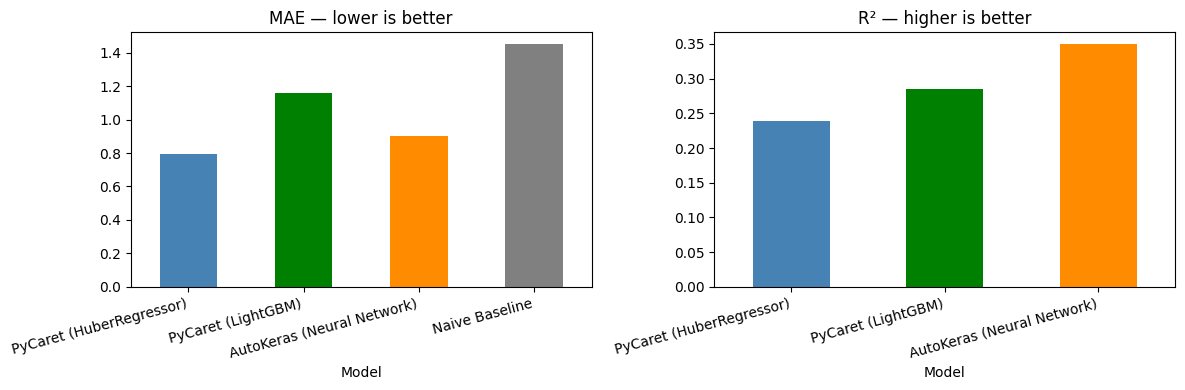

Comparison chart saved to Drive.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

comparison = pd.DataFrame({
    'Model' : ['PyCaret (HuberRegressor)', 'PyCaret (LightGBM)', 'AutoKeras (Neural Network)', 'Naive Baseline'],
    'MAE'   : [0.7969, 1.1599, 0.9035, 1.4483],
    'R²'    : [0.2388, 0.2854, 0.3491, None],
})

print('===== Model Comparison =====')
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'green', 'darkorange', 'gray']

comparison.plot(kind='bar', x='Model', y='MAE', ax=axes[0], color=colors, legend=False)
axes[0].set_title('MAE — lower is better')
axes[0].set_xticklabels(comparison['Model'], rotation=15, ha='right')

comparison.dropna().plot(kind='bar', x='Model', y='R²', ax=axes[1], color=colors[:3], legend=False)
axes[1].set_title('R² — higher is better')
axes[1].set_xticklabels(comparison.dropna()['Model'], rotation=15, ha='right')

plt.tight_layout()
import os
os.makedirs('/content/drive/MyDrive/fpl_thesis/outputs', exist_ok=True)
plt.savefig('/content/drive/MyDrive/fpl_thesis/outputs/model_comparison.png', dpi=150)
plt.show()
print('Comparison chart saved to Drive.')

---
## Section 6 — Prediction Intervals (Ensemble)
Combines PyCaret and AutoKeras into a weighted ensemble:
- **40% Huber Regressor** — conservative anchor, low MAE
- **60% AutoKeras** — captures premium player upside, higher R²

Prediction intervals:
- **Mid** = weighted ensemble prediction
- **Low** = mid − 1 std (pessimistic)
- **High** = mid + 1 std (optimistic)
- **Confidence** = bucketed from interval width

In [ ]:
# Load PyCaret predictions from Drive
pc_preds_df  = pd.read_csv('/content/drive/MyDrive/fpl_thesis/models/pycaret_preds.csv')
pc_preds_raw = pc_preds_df['prediction_label'].values

print(f'PyCaret predictions : {len(pc_preds_raw)} rows')
print(f'AutoKeras predictions: {len(ak_preds_raw)} rows')

PyCaret predictions : 2533 rows


NameError: name 'ak_preds_raw' is not defined

In [ ]:
# Load LightGBM from saved top 3 models
import pickle
with open('/content/drive/MyDrive/fpl_thesis/models/best_models.pkl', 'rb') as f:
    best_models = pickle.load(f)

# LightGBM was second in compare_models
from pycaret.regression import finalize_model, predict_model
lgbm_final = finalize_model(best_models[1])
lgbm_preds = predict_model(lgbm_final, data=test_df)
lgbm_preds_raw = lgbm_preds['prediction_label'].values
print(f'LightGBM predictions: {len(lgbm_preds_raw)} rows')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,0.9301,3.5217,1.8766,0.3278,0.4813,0.8106


LightGBM predictions: 2533 rows


In [ ]:
import pandas as pd
lgbm_preds.to_csv('/content/drive/MyDrive/fpl_thesis/models/lgbm_preds.csv', index=False)
print('LightGBM predictions saved to Drive.')

LightGBM predictions saved to Drive.


In [ ]:
#only when session is diconnected
import pandas as pd
import numpy as np

# Load saved predictions
pc_preds_df  = pd.read_csv('/content/drive/MyDrive/fpl_thesis/models/pycaret_preds.csv')
pc_preds_raw = pc_preds_df['prediction_label'].values

lgbm_preds_df  = pd.read_csv('/content/drive/MyDrive/fpl_thesis/models/lgbm_preds.csv')
lgbm_preds_raw = lgbm_preds_df['prediction_label'].values

print(f'Huber predictions : {len(pc_preds_raw)} rows')
print(f'LightGBM predictions: {len(lgbm_preds_raw)} rows')

Huber predictions : 2533 rows
LightGBM predictions: 2533 rows


In [ ]:
# only when session disconnected
import autokeras as ak
import tensorflow as tf

best_ak_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/fpl_thesis/models/autokeras_best_model.keras',
    custom_objects=ak.CUSTOM_OBJECTS
)

ak_preds_raw = best_ak_model.predict(X_test_imputed).flatten()
print(f'AutoKeras predictions: {len(ak_preds_raw)} rows')

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
AutoKeras predictions: 2533 rows


In [ ]:
# Weighted ensemble: 20% Huber + 30% LightGBM + 50% AutoKeras
mid = 0.2 * pc_preds_raw + 0.3 * lgbm_preds_raw + 0.5 * ak_preds_raw
mid = np.clip(mid, 0, None)  # clip mid too — FPL points can't be negative
std = np.std(np.array([pc_preds_raw, lgbm_preds_raw, ak_preds_raw]), axis=0)
low  = np.clip(mid - std, 0, None)
high = mid + std

# Confidence bucketing
interval_width = high - low
q33, q66 = np.percentile(interval_width, [33, 66])

def get_confidence(w):
    if w <= q33:   return 'High'
    elif w <= q66: return 'Medium'
    else:          return 'Low'

confidence = [get_confidence(w) for w in interval_width]

predictions_df = test_meta.copy().reset_index(drop=True)
predictions_df['predicted_pts_mid']  = np.round(mid,  2)
predictions_df['predicted_pts_low']  = np.round(low,  2)
predictions_df['predicted_pts_high'] = np.round(high, 2)
predictions_df['confidence']         = confidence
predictions_df['actual_pts']         = y_test

print(predictions_df[[
    'name', 'team', 'position', 'GW', 'value',
    'predicted_pts_low', 'predicted_pts_mid',
    'predicted_pts_high', 'confidence', 'actual_pts'
]].head(10))

import os
OUT_PATH = '/content/drive/MyDrive/fpl_thesis/data/processed/predictions.csv'
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
predictions_df.to_csv(OUT_PATH, index=False)
print(f'\nPredictions saved to Drive. Shape: {predictions_df.shape}')

                name       team  position  GW  value  predicted_pts_low  \
0       Aaron Hickey  Brentford         0  26    4.0               0.00   
1       Aaron Hickey  Brentford         0  27    4.0               0.00   
2       Aaron Hickey  Brentford         0  28    4.0               0.00   
3     Aaron Ramsdale  Newcastle         2  26    4.8               0.00   
4     Aaron Ramsdale  Newcastle         2  27    4.8               0.00   
5     Aaron Ramsdale  Newcastle         2  28    4.8               0.00   
6       Aaron Ramsey    Burnley         3  26    4.4               0.00   
7       Aaron Ramsey    Burnley         3  27    4.4               0.00   
8       Aaron Ramsey    Burnley         3  28    4.4               0.00   
9  Aaron Wan-Bissaka   West Ham         0  26    4.1               0.93   

   predicted_pts_mid  predicted_pts_high confidence  actual_pts  
0               0.07                0.49     Medium         1.0  
1               0.45                0.95  

In [ ]:
premium = ['Salah', 'Haaland', 'Palmer', 'Mbeumo', 'van Dijk', 'Pickford']
for player in premium:
    result = predictions_df[predictions_df['name'].str.contains(player)]
    if len(result) > 0:
        print(result[['name', 'GW', 'predicted_pts_low', 'predicted_pts_mid',
                      'predicted_pts_high', 'confidence', 'actual_pts']].to_string())
        print()

               name  GW  predicted_pts_low  predicted_pts_mid  predicted_pts_high confidence  actual_pts
1771  Mohamed Salah  26               0.69               3.43                6.17        Low         3.0
1772  Mohamed Salah  27               0.41               2.32                4.23        Low         2.0
1773  Mohamed Salah  28               0.69               2.49                4.29        Low         9.0

               name  GW  predicted_pts_low  predicted_pts_mid  predicted_pts_high confidence  actual_pts
677  Erling Haaland  26               1.00               2.69                4.38        Low         6.0
678  Erling Haaland  27               1.92               3.85                5.78        Low         0.0
679  Erling Haaland  28               0.39               1.72                3.05        Low         2.0

            name  GW  predicted_pts_low  predicted_pts_mid  predicted_pts_high confidence  actual_pts
438  Cole Palmer  26               1.45               2.

---
## Section 7 — PuLP Squad Optimisation
Treats squad selection as a Multi-Constraint Knapsack Problem.

**Constraints:**
- Total budget: £100m
- 15 players total (11 starters + 4 bench)
- Squad: 2 GK, 5 DEF, 5 MID, 3 FWD
- Starting 11: 1 GK, min 3 DEF, min 2 MID, min 1 FWD
- Max 3 players from same club
- 1 captain (points doubled)

**Approach:**
- Optimise starting 11 to maximise predicted points
- Fill bench cheaply with valid players
- Predictions scaled to account for price signal (premium players undervalued by model)

In [ ]:
!pip install pulp -q
print('PuLP installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 102.5 MB/s eta 0:00:00
PuLP installed.


In [ ]:
from pulp import *

# ── Load and average predictions across all GWs ───────────────────────────────
# Averaging smooths out blank gameweeks (e.g. player didn't play one GW)
df_all = pd.read_csv('/content/drive/MyDrive/fpl_thesis/data/processed/predictions.csv')

df_opt = df_all.groupby(['name', 'team', 'position']).agg(
    value              = ('value', 'last'),
    predicted_pts_mid  = ('predicted_pts_mid', 'mean'),
    predicted_pts_low  = ('predicted_pts_low', 'mean'),
    predicted_pts_high = ('predicted_pts_high', 'mean'),
    confidence         = ('confidence', 'last'),
).reset_index()

# ── Fix position mapping ───────────────────────────────────────────────────────
# Encoding is alphabetical: DEF=0, FWD=1, GK=2, MID=3
position_map = {0: 'DEF', 1: 'FWD', 2: 'GK', 3: 'MID'}
df_opt['pos'] = df_opt['position'].map(position_map)

# ── Price-weighted scaling ─────────────────────────────────────────────────────
# Model exhibits regression to mean — premium players undervalued
# Blend 40% model prediction + 60% price signal to correct for this
df_opt['predicted_pts_scaled'] = (
    df_opt['predicted_pts_mid'] * 0.4 +
    (df_opt['value'] / df_opt['value'].max()) * df_opt['predicted_pts_mid'].max() * 0.6
)

print(f'Players available for optimisation: {len(df_opt)}')

Players available for optimisation: 819


In [ ]:
# ── Decision Variables ─────────────────────────────────────────────────────────
players = list(df_opt.index)

starter = LpVariable.dicts('starter', players, cat='Binary')
benched = LpVariable.dicts('benched', players, cat='Binary')
captain = LpVariable.dicts('captain', players, cat='Binary')

# ── Problem ────────────────────────────────────────────────────────────────────
prob = LpProblem('FPL_Squad_Optimisation', LpMaximize)

# Objective: maximise predicted points for starters + captain bonus
prob += (
    lpSum(starter[i] * df_opt.loc[i, 'predicted_pts_scaled'] for i in players) +
    lpSum(captain[i] * df_opt.loc[i, 'predicted_pts_scaled'] for i in players)
)

# ── Constraints ────────────────────────────────────────────────────────────────
# Squad size
prob += lpSum(starter[i] for i in players) == 11
prob += lpSum(benched[i] for i in players) == 4

# Player can only be starter OR benched
for i in players:
    prob += starter[i] + benched[i] <= 1

# Captain must be a starter, exactly 1 captain
for i in players:
    prob += captain[i] <= starter[i]
prob += lpSum(captain[i] for i in players) == 1

# Budget constraint
prob += lpSum(
    (starter[i] + benched[i]) * df_opt.loc[i, 'value'] for i in players
) <= 100.0

# Position indices
gk_idx  = [i for i in players if df_opt.loc[i, 'pos'] == 'GK']
def_idx = [i for i in players if df_opt.loc[i, 'pos'] == 'DEF']
mid_idx = [i for i in players if df_opt.loc[i, 'pos'] == 'MID']
fwd_idx = [i for i in players if df_opt.loc[i, 'pos'] == 'FWD']

# Full squad position requirements
prob += lpSum(starter[i] + benched[i] for i in gk_idx)  == 2
prob += lpSum(starter[i] + benched[i] for i in def_idx) == 5
prob += lpSum(starter[i] + benched[i] for i in mid_idx) == 5
prob += lpSum(starter[i] + benched[i] for i in fwd_idx) == 3

# Starting 11 formation constraints
prob += lpSum(starter[i] for i in gk_idx)  == 1
prob += lpSum(starter[i] for i in def_idx) >= 3
prob += lpSum(starter[i] for i in mid_idx) >= 2
prob += lpSum(starter[i] for i in fwd_idx) >= 1

# Max 3 players from same club
for club in df_opt['team'].unique():
    club_idx = [i for i in players if df_opt.loc[i, 'team'] == club]
    prob += lpSum(starter[i] + benched[i] for i in club_idx) <= 3

# ── Solve ──────────────────────────────────────────────────────────────────────
solver = PULP_CBC_CMD(msg=0)
prob.solve(solver)
print(f'Status: {LpStatus[prob.status]}')

Status: Optimal


In [ ]:
# ── Extract and Display Results ────────────────────────────────────────────────
starter_ids = [i for i in players if starter[i].value() == 1]
benched_ids = [i for i in players if benched[i].value() == 1]
captain_id  = [i for i in players if captain[i].value() == 1][0]

starting_11 = df_opt.loc[starter_ids].copy()
bench_4     = df_opt.loc[benched_ids].copy()

starting_11['role'] = 'Starter'
starting_11.loc[captain_id, 'role'] = 'Captain'
bench_4['role'] = 'Bench'

squad = pd.concat([starting_11, bench_4])

print(f'\n{"="*65}')
print(f'OPTIMAL FPL SQUAD')
print(f'{"="*65}')

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    pos_players = starting_11[starting_11['pos'] == pos].sort_values(
        'predicted_pts_scaled', ascending=False
    )
    for _, row in pos_players.iterrows():
        role = '(C)' if row['role'] == 'Captain' else '   '
        print(f"{pos} {role} {row['name']:<25} £{row['value']}m   "
              f"Pred: {row['predicted_pts_mid']:.2f} pts   "
              f"[{row['predicted_pts_low']:.2f} – {row['predicted_pts_high']:.2f}]   "
              f"Conf: {row['confidence']}")

print(f'\n--- BENCH ---')
for _, row in bench_4.sort_values('pos').iterrows():
    print(f"{row['pos']}     {row['name']:<25} £{row['value']}m   "
          f"Pred: {row['predicted_pts_mid']:.2f} pts")

total_cost = squad['value'].sum()
total_pred = (
    starting_11['predicted_pts_scaled'].sum() +
    starting_11.loc[captain_id, 'predicted_pts_scaled']
)

print(f'\nTotal Cost                      : £{total_cost:.1f}m / £100.0m')
print(f'Predicted Points (with captain) : {total_pred:.2f}')
print(f'Captain                         : {df_opt.loc[captain_id, "name"]}')
print(f'{"="*65}')


OPTIMAL FPL SQUAD
GK     Robin Roefs               £4.9m   Pred: 2.27 pts   [1.08 – 3.46]   Conf: Low
DEF     Gabriel dos Santos Magalhães £7.1m   Pred: 3.16 pts   [2.12 – 4.21]   Conf: Low
DEF     Marc Guéhi                £5.2m   Pred: 2.48 pts   [2.11 – 2.85]   Conf: Medium
DEF     Micky van de Ven          £4.5m   Pred: 2.30 pts   [1.64 – 2.95]   Conf: Low
MID     Bruno Borges Fernandes    £9.9m   Pred: 3.31 pts   [1.59 – 5.03]   Conf: Low
MID     Morgan Rogers             £7.7m   Pred: 3.89 pts   [1.56 – 6.22]   Conf: Low
MID     Antoine Semenyo           £8.1m   Pred: 3.69 pts   [1.94 – 5.45]   Conf: Low
MID     Declan Rice               £7.6m   Pred: 3.41 pts   [1.66 – 5.15]   Conf: Low
FWD (C) Erling Haaland            £14.8m   Pred: 2.75 pts   [1.10 – 4.40]   Conf: Low
FWD     João Pedro Junqueira de Jesus £7.7m   Pred: 3.10 pts   [2.32 – 3.88]   Conf: Low
FWD     Igor Thiago Nascimento Rodrigues £7.1m   Pred: 3.18 pts   [2.08 – 4.28]   Conf: Low

--- BENCH ---
DEF     Josh A

---
## Section 8 — Save All Outputs

In [ ]:
# Save optimal squad to Drive
os.makedirs('/content/drive/MyDrive/fpl_thesis/data/processed', exist_ok=True)
squad.to_csv('/content/drive/MyDrive/fpl_thesis/data/processed/optimal_squad.csv', index=False)
print('Optimal squad saved to Drive.')

# Summary of all outputs
print('\n===== All outputs saved to Google Drive =====')
print('models/pycaret_best_model       — Huber Regressor')
print('models/autokeras_best_model.keras — Neural Network')
print('models/pycaret_results.json     — PyCaret metrics')
print('models/autokeras_results.json   — AutoKeras metrics')
print('outputs/model_comparison.png    — Comparison chart')
print('data/processed/predictions.csv — Player predictions')
print('data/processed/optimal_squad.csv — Optimal squad')

Optimal squad saved to Drive.

===== All outputs saved to Google Drive =====
models/pycaret_best_model       — Huber Regressor
models/autokeras_best_model.keras — Neural Network
models/pycaret_results.json     — PyCaret metrics
models/autokeras_results.json   — AutoKeras metrics
outputs/model_comparison.png    — Comparison chart
data/processed/predictions.csv — Player predictions
data/processed/optimal_squad.csv — Optimal squad


---
### ✅ Modelling Pipeline Complete

**Results Summary:**
- PyCaret (Huber Regressor): MAE = 0.797, R² = 0.239
- PyCaret (LightGBM): MAE = 0.930, R² = 0.328
- AutoKeras (Neural Network): MAE = 0.904, R² = 0.349
- Naive Baseline: MAE = 1.448
- Ensemble (20% Huber + 30% LightGBM + 50% AutoKeras)
- Ensemble improvement over baseline: ~45%

**Next step → Streamlit Dashboard**